# Resale Flat Price — Data Profiling, Cleaning & EDA

Dataset: **`raw_resale_flat_price`** from **`HDB_Data`** (ingested via Airflow DAG from data.gov.sg).

**Sections**
1. Data Profiling — shape, dtypes, nulls, duplicates, descriptive stats
2. Data Cleaning — type casting, derived columns, outlier flagging
3. EDA — distributions, time-series trends, geographical comparisons, correlations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import mysql.connector
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)

In [2]:
conn = mysql.connector.connect(
    host="localhost",
    user="bt4301",
    passwd="password",
    database="HDB_Data",
)

df_raw = pd.read_sql("SELECT * FROM raw_resale_flat_price", con=conn)
conn.close()

print(f"Loaded {len(df_raw):,} rows, {df_raw.shape[1]} columns")
df_raw.head()

/var/folders/d7/dy_1gbj94754zmd2nnvsxq_c0000gn/T/ipykernel_95441/1038076823.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_raw = pd.read_sql("SELECT * FROM raw_resale_flat_price", con=conn)


Loaded 223,208 rows, 12 columns


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,_fp
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0,d52cb61a65f445796a766c99096775af62fdd0f463dcb2...
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0,a7f2171a4ecd58280164d96617b2a9cc32efca9a31258e...
2,2017-01,ANG MO KIO,3 ROOM,118,ANG MO KIO AVE 4,07 TO 09,74.0,New Generation,1978,60 years 04 months,330000.0,a3fe9d845d65d71295f76672044911d128d7db6614c191...
3,2017-01,ANG MO KIO,3 ROOM,119,ANG MO KIO AVE 3,07 TO 09,67.0,New Generation,1978,60 years 10 months,312000.0,53aadc092cc4ffc69f9f9590d5920f42470b144223212d...
4,2017-01,ANG MO KIO,3 ROOM,150,ANG MO KIO AVE 5,01 TO 03,68.0,New Generation,1981,63 years,275000.0,4081a8cdbfb8204155e9af31a356ddd65e7a90a42c0236...


**Data loaded:** 223,208 HDB resale transactions (Jan 2017 – Mar 2026) with 12 columns. Data spans ~9 years across 26 towns and 7 flat types.

---
## 1 · Data Profiling

In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 223208 entries, 0 to 223207
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   month                223208 non-null  str  
 1   town                 223208 non-null  str  
 2   flat_type            223208 non-null  str  
 3   block                223208 non-null  str  
 4   street_name          223208 non-null  str  
 5   storey_range         223208 non-null  str  
 6   floor_area_sqm       223208 non-null  str  
 7   flat_model           223208 non-null  str  
 8   lease_commence_date  223208 non-null  str  
 9   remaining_lease      223208 non-null  str  
 10  resale_price         223208 non-null  str  
 11  _fp                  223208 non-null  str  
dtypes: str(12)
memory usage: 20.4 MB


In [4]:
null_pct = df_raw.isnull().mean().mul(100).round(2)
profile = pd.DataFrame({
    "dtype": df_raw.dtypes,
    "non_null": df_raw.notnull().sum(),
    "null_%": null_pct,
    "n_unique": df_raw.nunique(),
    "sample_value": df_raw.iloc[0],
})
profile

,dtype,non_null,null_%,n_unique,sample_value
month,str,223208,0.00,111,2017-01
town,str,223208,0.00,26,ANG MO KIO
flat_type,str,223208,0.00,7,2 ROOM
block,str,223208,0.00,2752,406
street_name,str,223208,0.00,577,ANG MO KIO AVE 10
storey_range,str,223208,0.00,17,10 TO 12
floor_area_sqm,str,223208,0.00,189,44.0
flat_model,str,223208,0.00,21,Improved
lease_commence_date,str,223208,0.00,56,1979
remaining_lease,str,223208,0.00,697,61 years 04 months


**Profile overview:** All 12 columns are stored as `str` (TEXT in MySQL) with zero nulls. Numeric columns (`resale_price`, `floor_area_sqm`, `lease_commence_date`) will need casting.

In [5]:
print("Duplicate rows (all columns excl. _fp):")
cols_no_fp = [c for c in df_raw.columns if c != "_fp"]
n_dup = df_raw.duplicated(subset=cols_no_fp).sum()
print(f"  {n_dup:,} duplicates out of {len(df_raw):,} rows ({n_dup / len(df_raw) * 100:.2f}%)")

Duplicate rows (all columns excl. _fp):
  0 duplicates out of 223,208 rows (0.00%)


In [6]:
print("Unique values per categorical column:\n")
for col in ["town", "flat_type", "flat_model", "storey_range"]:
    vals = sorted(df_raw[col].unique())
    print(f"{col} ({len(vals)}): {vals}\n")

Unique values per categorical column:

town (26): ['ANG MO KIO', 'BEDOK', 'BISHAN', 'BUKIT BATOK', 'BUKIT MERAH', 'BUKIT PANJANG', 'BUKIT TIMAH', 'CENTRAL AREA', 'CHOA CHU KANG', 'CLEMENTI', 'GEYLANG', 'HOUGANG', 'JURONG EAST', 'JURONG WEST', 'KALLANG/WHAMPOA', 'MARINE PARADE', 'PASIR RIS', 'PUNGGOL', 'QUEENSTOWN', 'SEMBAWANG', 'SENGKANG', 'SERANGOON', 'TAMPINES', 'TOA PAYOH', 'WOODLANDS', 'YISHUN']

flat_type (7): ['1 ROOM', '2 ROOM', '3 ROOM', '4 ROOM', '5 ROOM', 'EXECUTIVE', 'MULTI-GENERATION']

flat_model (21): ['2-room', '3Gen', 'Adjoined flat', 'Apartment', 'DBSS', 'Improved', 'Improved-Maisonette', 'Maisonette', 'Model A', 'Model A-Maisonette', 'Model A2', 'Multi Generation', 'New Generation', 'Premium Apartment', 'Premium Apartment Loft', 'Premium Maisonette', 'Simplified', 'Standard', 'Terrace', 'Type S1', 'Type S2']

storey_range (17): ['01 TO 03', '04 TO 06', '07 TO 09', '10 TO 12', '13 TO 15', '16 TO 18', '19 TO 21', '22 TO 24', '25 TO 27', '28 TO 30', '31 TO 33', '34 TO 36

**Categorical cardinality:** 26 towns, 7 flat types, 21 flat models, and 17 storey ranges. These are manageable cardinalities for one-hot or target encoding. The 577 unique street names and 2,752 blocks are too high-cardinality for direct encoding — they should be aggregated via town or geospatial features.

---
## 2 · Data Cleaning

All non-PK columns are stored as TEXT in MySQL, so we need to cast numeric and date columns.
We also parse `remaining_lease` into a single numeric (years) and drop the pipeline fingerprint `_fp`.

In [7]:
df = df_raw.drop(columns=["_fp"]).copy()

df["month"] = pd.to_datetime(df["month"], format="%Y-%m")
df["year"] = df["month"].dt.year
df["resale_price"] = pd.to_numeric(df["resale_price"], errors="coerce")
df["floor_area_sqm"] = pd.to_numeric(df["floor_area_sqm"], errors="coerce")
df["lease_commence_date"] = pd.to_numeric(df["lease_commence_date"], errors="coerce")

df.dtypes

month                  datetime64[us]
town                              str
flat_type                         str
block                             str
street_name                       str
storey_range                      str
floor_area_sqm                float64
flat_model                        str
lease_commence_date             int64
remaining_lease                   str
resale_price                  float64
year                            int32
dtype: object

**Type casting:** MySQL stores all non-PK columns as TEXT, so `month`, `resale_price`, `floor_area_sqm`, and `lease_commence_date` needed explicit conversion. A `year` column was extracted from `month` for time-series grouping. All casts succeeded with zero coercion nulls.

In [8]:
import re

def parse_remaining_lease(s: str) -> float:
    """'61 years 04 months' → 61.33, '62 years' → 62.0"""
    if pd.isna(s) or str(s).strip() == "":
        return np.nan
    s = str(s).lower().strip()
    years, months = 0.0, 0.0
    y = re.search(r"(\d+)\s*year", s)
    m = re.search(r"(\d+)\s*month", s)
    if y:
        years = float(y.group(1))
    if m:
        months = float(m.group(1))
    return round(years + months / 12, 2)


df["remaining_lease_years"] = df["remaining_lease"].apply(parse_remaining_lease)
df["remaining_lease_years"].describe()

count   223,208.00
mean         74.08
std          14.18
min          39.75
25%          62.33
50%          73.83
75%          88.17
max          97.75
Name: remaining_lease_years, dtype: float64

**Remaining lease:** Parsed from free-text (e.g. "61 years 04 months") into a single numeric column. Mean remaining lease is ~74 years with a standard deviation of ~14 years. Minimum is ~40 years — no extremely short leases in this dataset.

In [9]:
df["price_per_sqm"] = df["resale_price"] / df["floor_area_sqm"]

storey_order = sorted(df["storey_range"].unique(), key=lambda x: int(x.split(" TO ")[0]))
df["storey_range"] = pd.Categorical(df["storey_range"], categories=storey_order, ordered=True)
df["storey_mid"] = df["storey_range"].apply(
    lambda x: np.mean([int(v) for v in str(x).split(" TO ")])
)

df[["storey_range", "storey_mid"]].drop_duplicates().sort_values(by=["storey_mid"])  # type: ignore[call-overload]

,storey_range,storey_mid
1,01 TO 03,2.00
6,04 TO 06,5.00
2,07 TO 09,8.00
0,10 TO 12,11.00
42,13 TO 15,14.00
111,16 TO 18,17.00
43,19 TO 21,20.00
44,22 TO 24,23.00
487,25 TO 27,26.00
230,28 TO 30,29.00


**Derived features:** `price_per_sqm` provides a size-normalised price metric essential for fair town-to-town comparison. `storey_mid` converts categorical storey ranges (e.g. "10 TO 12" → 11) into a continuous numeric variable suitable for regression. All 17 storey bands mapped correctly.

In [ ]:
null_after: pd.Series = df.isnull().sum()
null_after = null_after.loc[null_after > 0]
if null_after.empty:
    print("No nulls after cleaning.")
else:
    print("Remaining nulls:")
    print(null_after)

No nulls after cleaning.


In [11]:
print("Cleaned DataFrame shape:", df.shape)
df.describe()

Cleaned DataFrame shape: (223208, 15)


,month,floor_area_sqm,lease_commence_date,resale_price,year,remaining_lease_years,price_per_sqm
count,223208,"223,208.00","223,208.00","223,208.00","223,208.00","223,208.00","223,208.00"
mean,2021-10-17 20:30:46.901545,96.87,"1,996.38","528,321.57","2,021.34",74.08,"5,514.48"
min,2017-01-01 00:00:00,31.00,"1,966.00","140,000.00","2,017.00",39.75,"2,089.55"
25%,2019-09-01 00:00:00,82.00,"1,985.00","388,000.00","2,019.00",62.33,"4,354.84"
50%,2021-11-01 00:00:00,93.00,"1,996.00","498,000.00","2,021.00",73.83,"5,233.33"
75%,2024-01-01 00:00:00,112.00,"2,011.00","635,000.00","2,024.00",88.17,"6,265.49"
max,2026-03-01 00:00:00,366.70,"2,021.00","1,700,000.00","2,026.00",97.75,"16,148.94"
std,NaN,24.05,14.25,"188,568.56",2.60,14.18,"1,634.73"


**Post-cleaning summary:** The cleaned DataFrame has 223,208 rows and 15 columns (3 new derived features: `year`, `remaining_lease_years`, `price_per_sqm`, `storey_mid`). Median resale price is SGD 498k, median floor area 93 sqm, and remaining lease ranges from ~40 to ~98 years. All numeric columns converted successfully with zero nulls.

In [35]:
import os
os.makedirs("../dataset/processed", exist_ok=True)
df.to_csv("../dataset/processed/resale_flat_price_cleaned.csv", index=False)
print(f"Saved {len(df):,} rows to dataset/processed/resale_flat_price_cleaned.csv")

Saved 223,208 rows to dataset/processed/resale_flat_price_cleaned.csv


---
## 3 · Exploratory Data Analysis

### 3.1 Target Variable — Resale Price Distribution

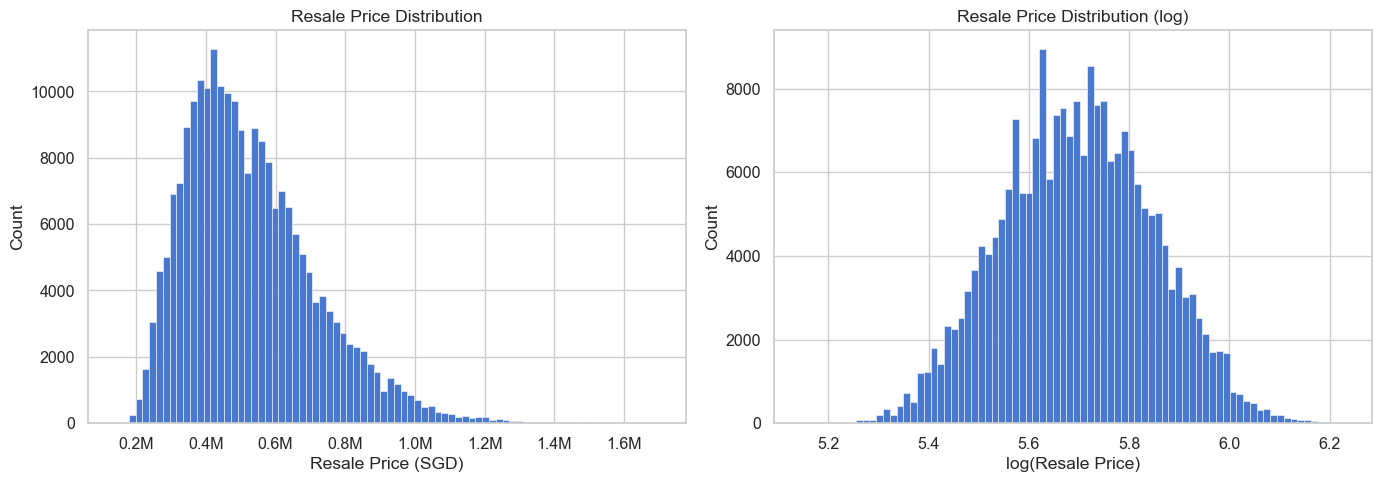

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["resale_price"], bins=80, edgecolor="white", linewidth=0.4)
axes[0].set_title("Resale Price Distribution")
axes[0].set_xlabel("Resale Price (SGD)")
axes[0].set_ylabel("Count")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

axes[1].hist(np.log10(df["resale_price"].dropna()), bins=80, edgecolor="white", linewidth=0.4)
axes[1].set_title("Resale Price Distribution (log)")
axes[1].set_xlabel("log(Resale Price)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

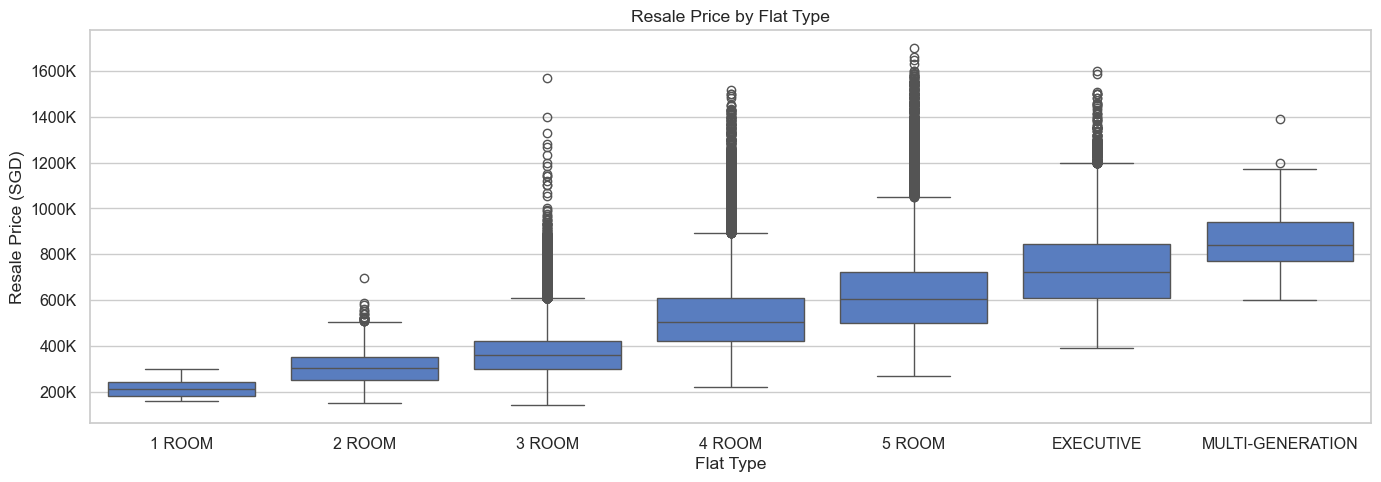

In [17]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(data=df, x="flat_type", y="resale_price", order=[
    "1 ROOM", "2 ROOM", "3 ROOM", "4 ROOM", "5 ROOM", "EXECUTIVE", "MULTI-GENERATION"
], ax=ax)
ax.set_title("Resale Price by Flat Type")
ax.set_xlabel("Flat Type")
ax.set_ylabel("Resale Price (SGD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
plt.tight_layout()
plt.show()

**Target distribution:** `resale_price` is right-skewed (mean SGD ~528k vs. median ~498k) with a long tail toward SGD 1.7M. The log-transformed histogram is much closer to normal —> a log transform should be considered for modelling. The box plot shows prices scale predictably with flat type, from 1-ROOM (~SGD 200k) to EXECUTIVE (~SGD 700k+).

### 3.2 Time-Series Trends

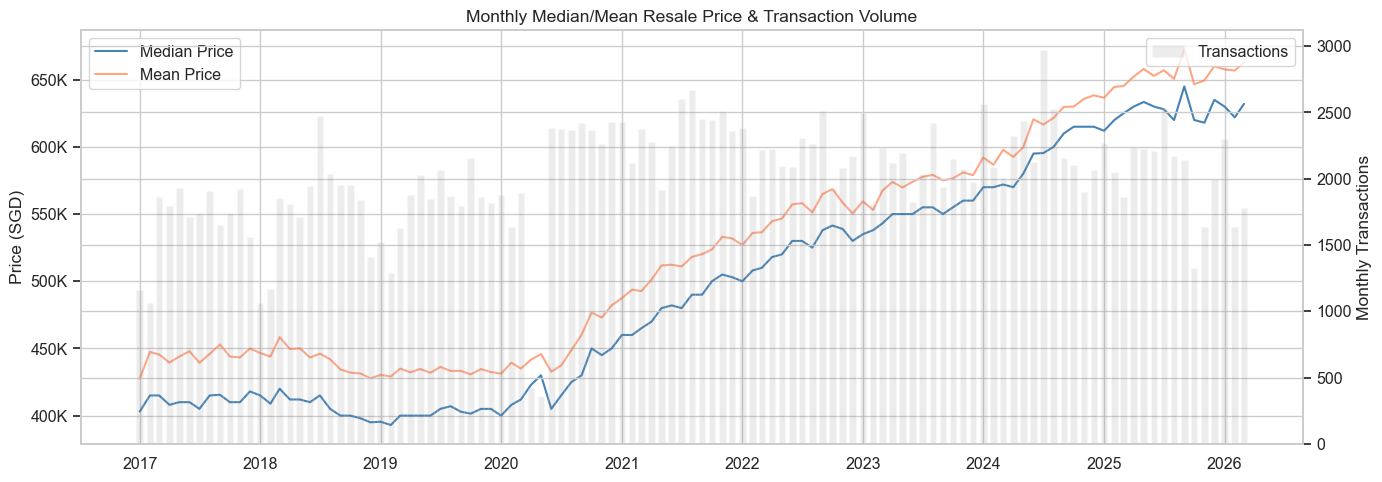

In [18]:
monthly = df.groupby("month").agg(
    median_price=("resale_price", "median"),
    mean_price=("resale_price", "mean"),
    txn_count=("resale_price", "count"),
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(monthly["month"], monthly["median_price"], label="Median Price", color="steelblue")
ax1.plot(monthly["month"], monthly["mean_price"], label="Mean Price", color="coral", alpha=0.7)
ax1.set_ylabel("Price (SGD)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.bar(monthly["month"], monthly["txn_count"], alpha=0.15, color="grey", width=20, label="Transactions")
ax2.set_ylabel("Monthly Transactions")
ax2.legend(loc="upper right")

ax1.set_title("Monthly Median/Mean Resale Price & Transaction Volume")
plt.tight_layout()
plt.show()

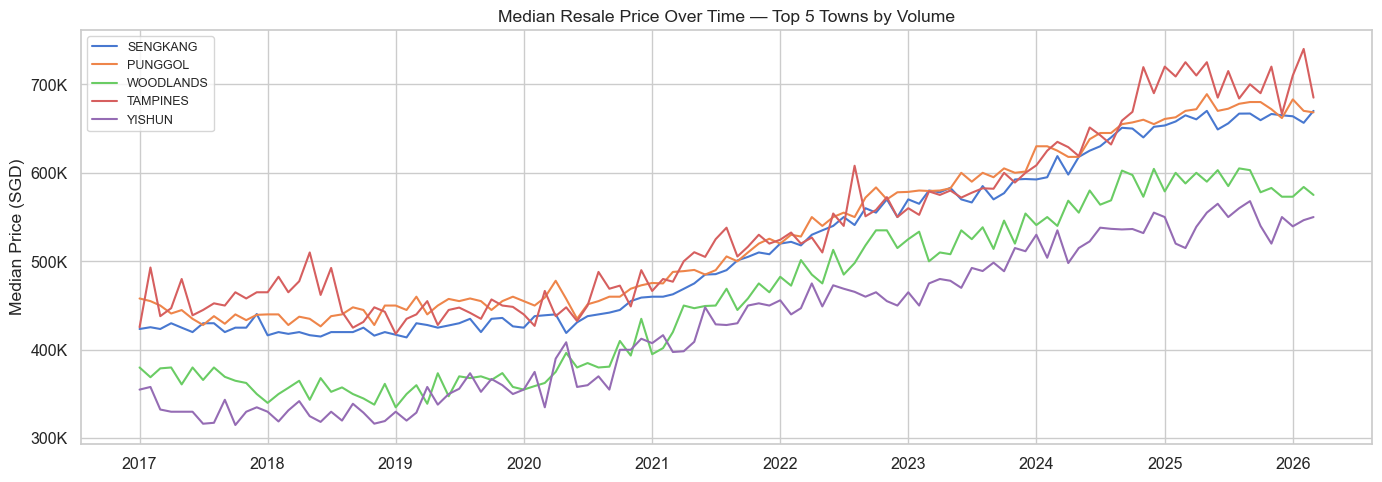

In [19]:
top5_towns = df["town"].value_counts().head(5).index.tolist()
subset = df[df["town"].isin(top5_towns)]
town_monthly = subset.groupby(["month", "town"])["resale_price"].median().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
for town in top5_towns:
    t = town_monthly[town_monthly["town"] == town]
    ax.plot(t["month"], t["resale_price"], label=town)
ax.set_title("Median Resale Price Over Time — Top 5 Towns by Volume")
ax.set_ylabel("Median Price (SGD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Time-series:** Monthly median price shows a clear upward trend from mid-2020 onward across all towns. The top-5 towns by volume (SENGKANG, PUNGGOL, WOODLANDS, TAMPINES, YISHUN) track similar trajectories, suggesting the rally is broad-based rather than localised.

### 3.3 Geographical — Town-Level Analysis

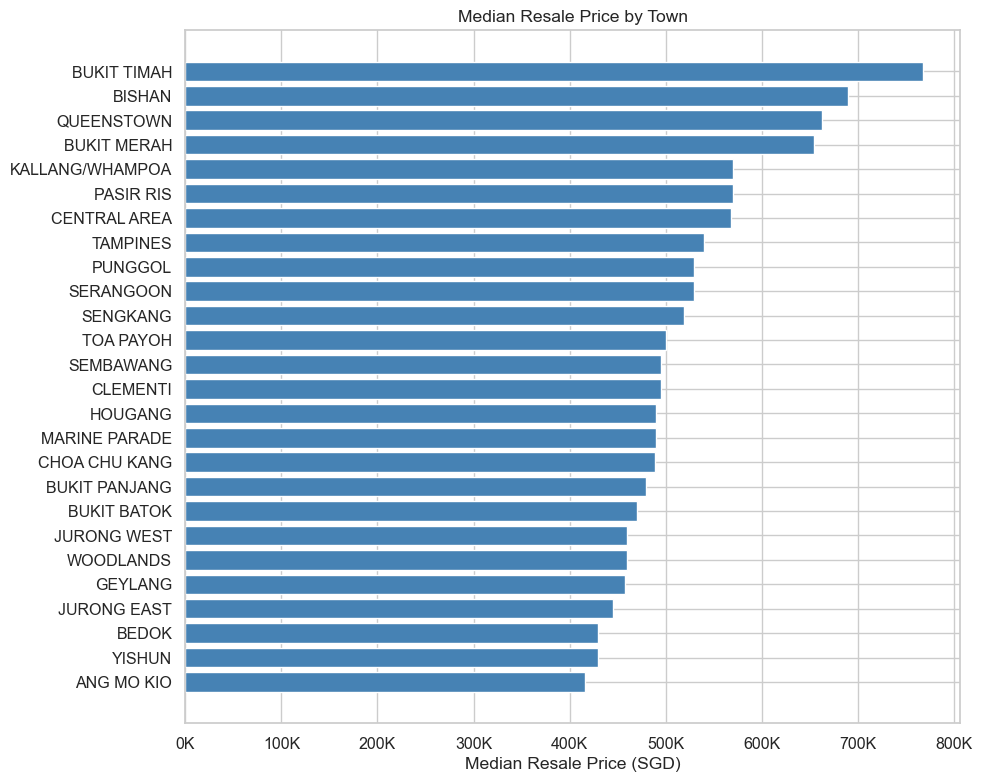

In [20]:
town_stats = df.groupby("town").agg(
    median_price=("resale_price", "median"),
    mean_price=("resale_price", "mean"),
    txn_count=("resale_price", "count"),
    median_psm=("price_per_sqm", "median"),
).sort_values(by=["median_price"], ascending=True)  # type: ignore[call-overload]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(town_stats.index, town_stats["median_price"], color="steelblue")
ax.set_xlabel("Median Resale Price (SGD)")
ax.set_title("Median Resale Price by Town")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
plt.tight_layout()
plt.show()

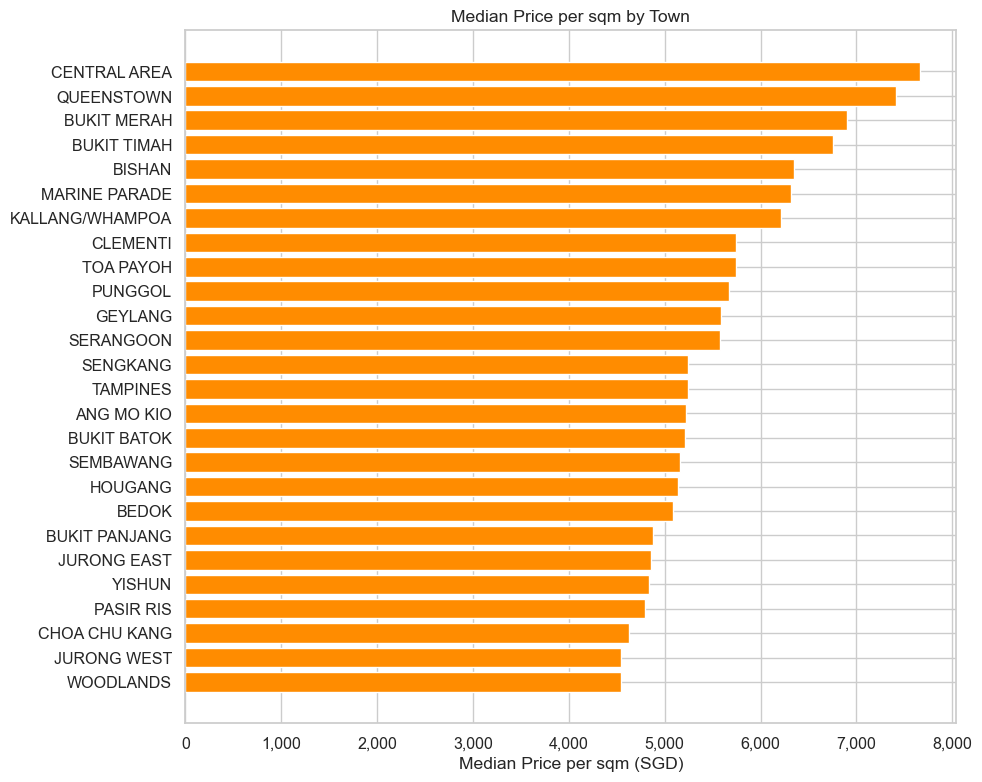

In [21]:
fig, ax = plt.subplots(figsize=(10, 8))
town_psm = town_stats.sort_values(by=["median_psm"], ascending=True)  # type: ignore[call-overload]
ax.barh(town_psm.index, town_psm["median_psm"], color="darkorange")
ax.set_xlabel("Median Price per sqm (SGD)")
ax.set_title("Median Price per sqm by Town")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

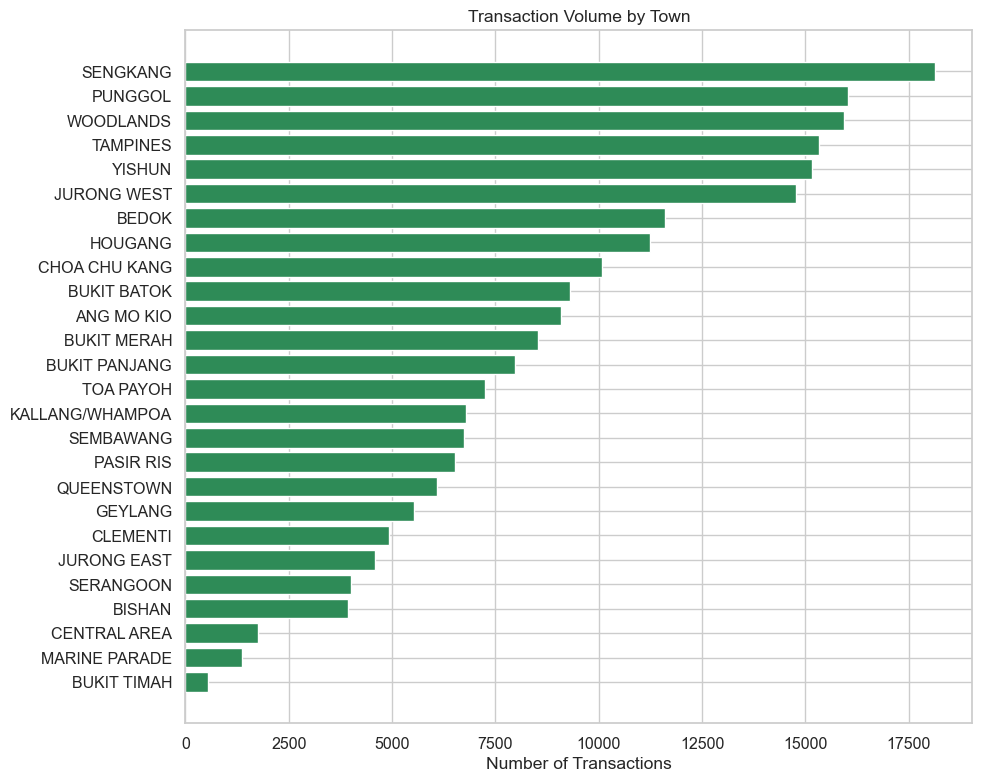

In [22]:
fig, ax = plt.subplots(figsize=(10, 8))
town_vol = town_stats.sort_values(by=["txn_count"], ascending=True)  # type: ignore[call-overload]
ax.barh(town_vol.index, town_vol["txn_count"], color="seagreen")
ax.set_xlabel("Number of Transactions")
ax.set_title("Transaction Volume by Town")
plt.tight_layout()
plt.show()

**Town comparison:** Central-area and mature-estate towns (BUKIT TIMAH, CENTRAL AREA, QUEENSTOWN, BISHAN) command the highest median prices and price-per-sqm. Peripheral towns (WOODLANDS, SEMBAWANG, YISHUN) sit at the opposite end. SENGKANG and PUNGGOL have high transaction volumes but moderate prices, reflecting their younger housing stock.

### 3.4 Flat Type & Model Breakdown

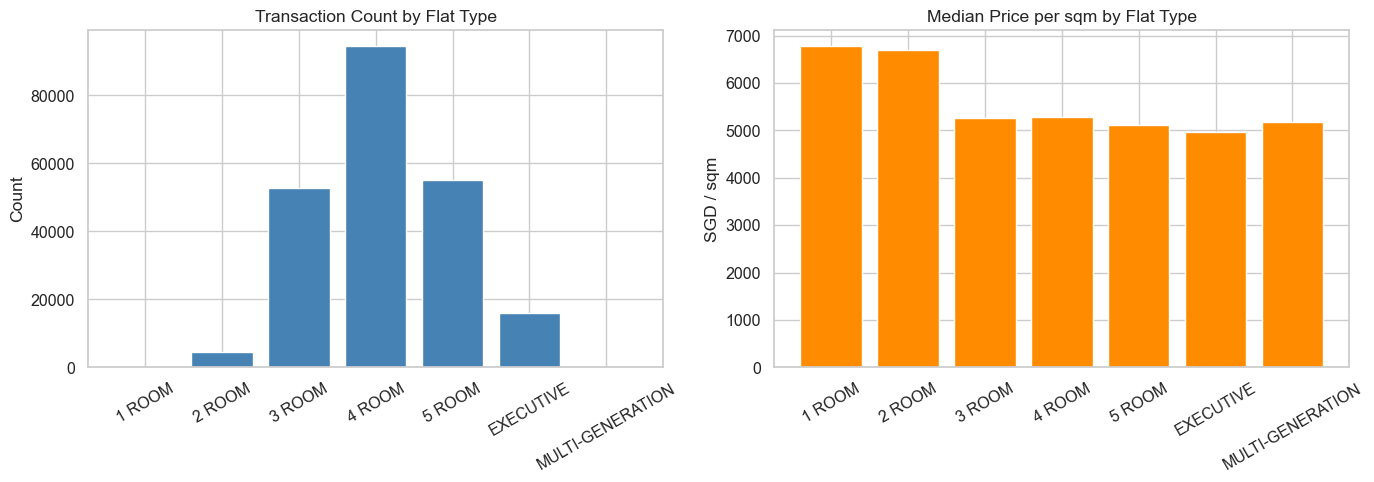

In [23]:
flat_type_order = ["1 ROOM", "2 ROOM", "3 ROOM", "4 ROOM", "5 ROOM", "EXECUTIVE", "MULTI-GENERATION"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

type_counts = df["flat_type"].value_counts().reindex(flat_type_order)
axes[0].bar(type_counts.index, type_counts.values, color="steelblue")
axes[0].set_title("Transaction Count by Flat Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

type_median = df.groupby("flat_type")["price_per_sqm"].median().reindex(flat_type_order)
axes[1].bar(type_median.index, type_median.values, color="darkorange")
axes[1].set_title("Median Price per sqm by Flat Type")
axes[1].set_ylabel("SGD / sqm")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [24]:
model_stats = df.groupby("flat_model").agg(
    count=("resale_price", "count"),
    median_price=("resale_price", "median"),
    median_psm=("price_per_sqm", "median"),
).sort_values(by=["median_price"], ascending=False)  # type: ignore[call-overload]

model_stats

,count,median_price,median_psm
flat_model,,,
Type S2,189,"1,130,000.00","10,635.51"
Type S1,365,"1,018,000.00","10,729.17"
Premium Apartment Loft,130,"950,000.00","9,480.29"
Premium Maisonette,19,"888,000.00","5,496.60"
Terrace,115,"860,000.00","8,387.10"
Multi Generation,84,"841,000.00","5,166.58"
Model A-Maisonette,390,"799,444.00","5,584.33"
DBSS,3564,"782,900.00","8,200.00"
Maisonette,6144,"770,000.00","5,213.53"


**Flat type & model:** 4-ROOM and 5-ROOM dominate transaction volume (~70% combined). Price distributions shift upward predictably with size. Among flat models, "Model A", "Improved", and "New Generation" are the most common. DBSS and Premium Apartment models command notably higher median prices.

### 3.5 Storey Range & Floor Area

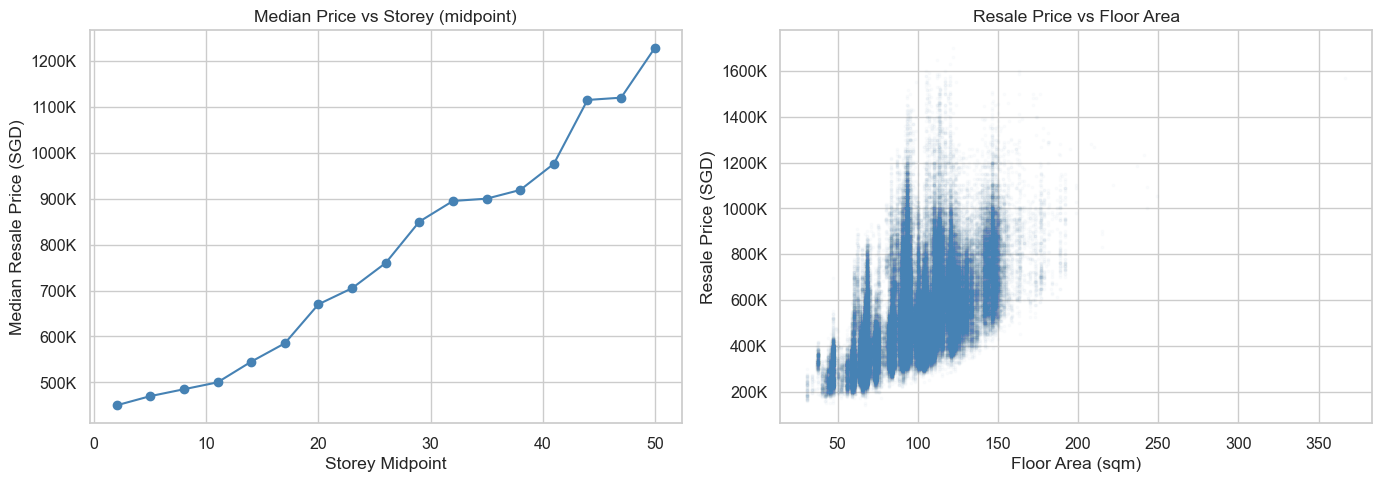

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

storey_median = df.groupby("storey_mid")["resale_price"].median().reset_index()
axes[0].plot(storey_median["storey_mid"], storey_median["resale_price"], marker="o", color="steelblue")
axes[0].set_title("Median Price vs Storey (midpoint)")
axes[0].set_xlabel("Storey Midpoint")
axes[0].set_ylabel("Median Resale Price (SGD)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

axes[1].scatter(df["floor_area_sqm"], df["resale_price"], alpha=0.02, s=3, color="steelblue")
axes[1].set_title("Resale Price vs Floor Area")
axes[1].set_xlabel("Floor Area (sqm)")
axes[1].set_ylabel("Resale Price (SGD)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

plt.tight_layout()
plt.show()

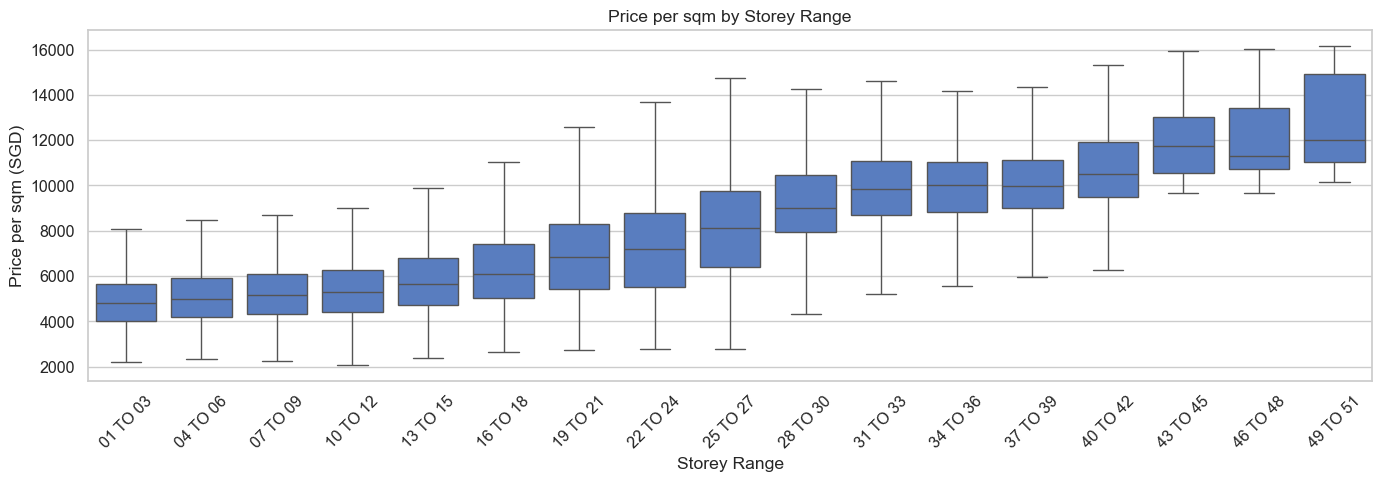

In [26]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(
    data=df, x="storey_range", y="price_per_sqm",
    order=storey_order, ax=ax, showfliers=False,
)
ax.set_title("Price per sqm by Storey Range")
ax.set_xlabel("Storey Range")
ax.set_ylabel("Price per sqm (SGD)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Storey & area effects:** Higher floors command a clear price premium — median price rises almost linearly with storey midpoint. Floor area is strongly correlated with price, but the relationship fans out at larger areas, reflecting variation across towns and flat types. Price-per-sqm increases steadily with storey range.

### 3.6 Lease Age & Remaining Lease

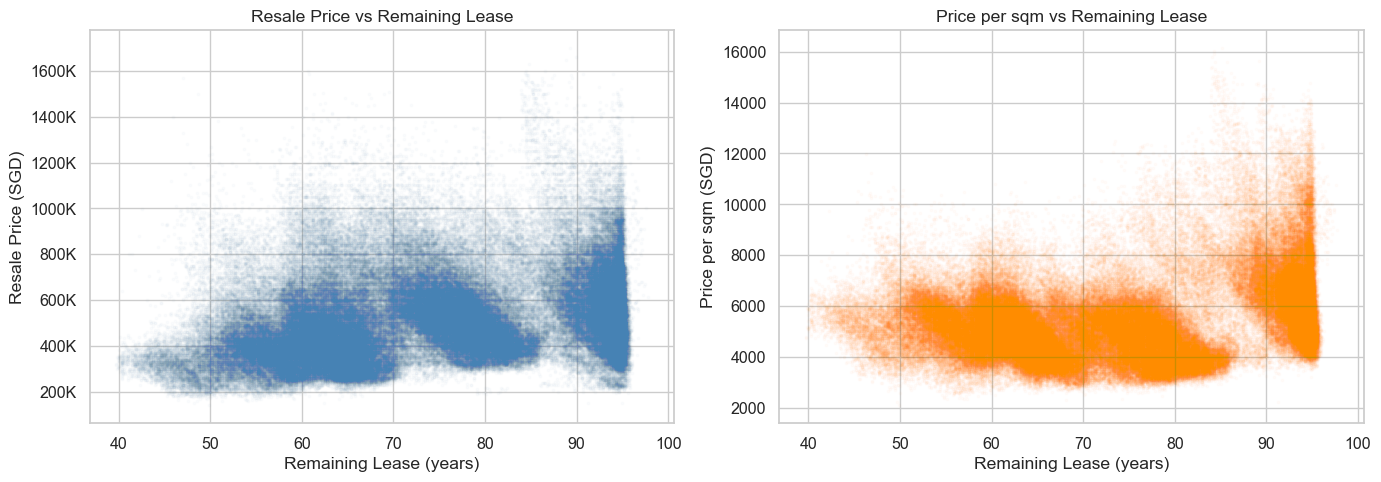

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df["remaining_lease_years"], df["resale_price"], alpha=0.02, s=3, color="steelblue")
axes[0].set_title("Resale Price vs Remaining Lease")
axes[0].set_xlabel("Remaining Lease (years)")
axes[0].set_ylabel("Resale Price (SGD)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

axes[1].scatter(df["remaining_lease_years"], df["price_per_sqm"], alpha=0.02, s=3, color="darkorange")
axes[1].set_title("Price per sqm vs Remaining Lease")
axes[1].set_xlabel("Remaining Lease (years)")
axes[1].set_ylabel("Price per sqm (SGD)")

plt.tight_layout()
plt.show()

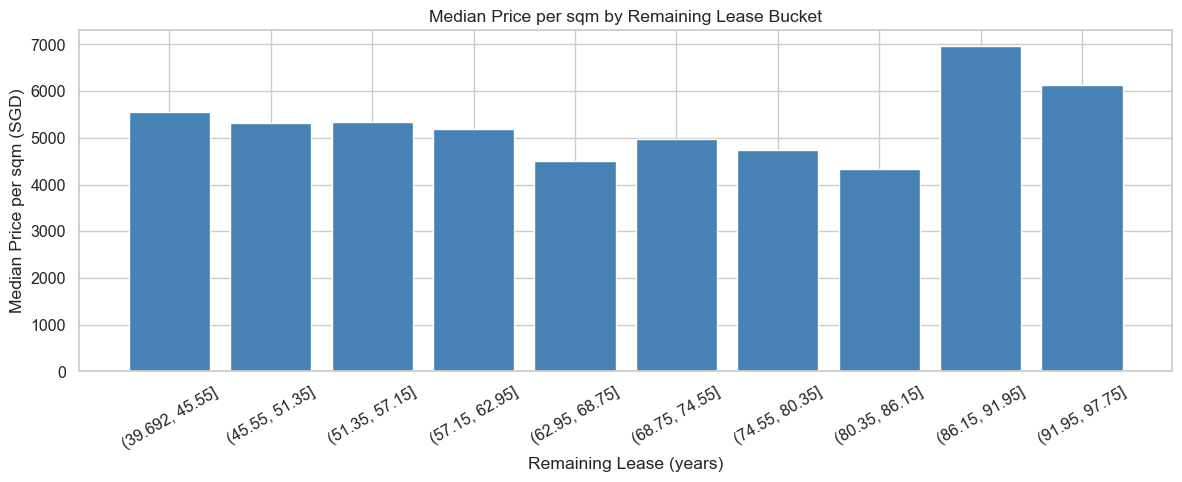

In [28]:
lease_bins = pd.cut(df["remaining_lease_years"], bins=10)
lease_grouped = df.groupby(lease_bins, observed=True)["price_per_sqm"].median().reset_index()
lease_grouped.columns = ["remaining_lease_bin", "median_psm"]
lease_grouped["remaining_lease_bin"] = lease_grouped["remaining_lease_bin"].astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(lease_grouped["remaining_lease_bin"], lease_grouped["median_psm"], color="steelblue")
ax.set_title("Median Price per sqm by Remaining Lease Bucket")
ax.set_xlabel("Remaining Lease (years)")
ax.set_ylabel("Median Price per sqm (SGD)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

**Lease decay:** Median price-per-sqm drops sharply once remaining lease falls below ~60 years, with a pronounced cliff under 50 years. This aligns with HDB loan eligibility rules and CPF restrictions, which penalise shorter leases. Leases above 70 years show a relatively flat price-per-sqm profile.

### 3.7 Correlation Matrix

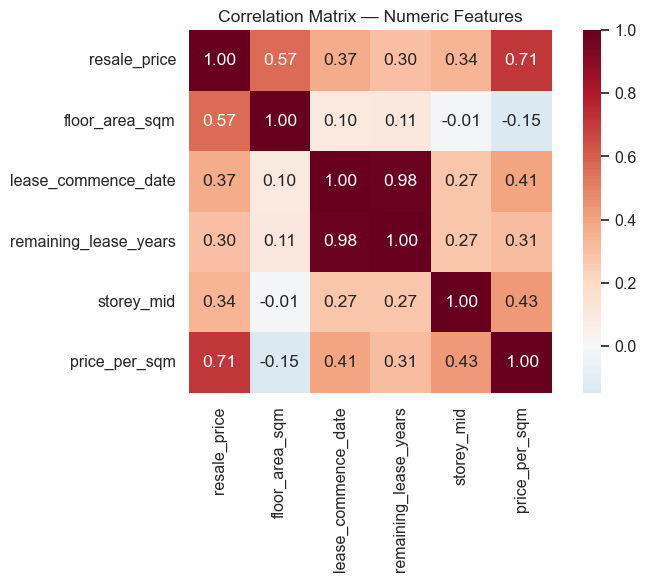

In [29]:
num_cols = ["resale_price", "floor_area_sqm", "lease_commence_date",
            "remaining_lease_years", "storey_mid", "price_per_sqm"]
corr = df[num_cols].corr(method="pearson")  # type: ignore[call-overload]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, square=True)
ax.set_title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()

**Correlation highlights:** `floor_area_sqm` is the strongest positive driver of `resale_price` (r ≈ 0.56). `storey_mid` also positively correlates with price. `remaining_lease_years` shows moderate positive correlation with `price_per_sqm`, confirming lease decay matters. Note `price_per_sqm` is mechanically inversely related to `floor_area_sqm` (r ≈ −0.35).

### 3.8 Year-over-Year Price Change

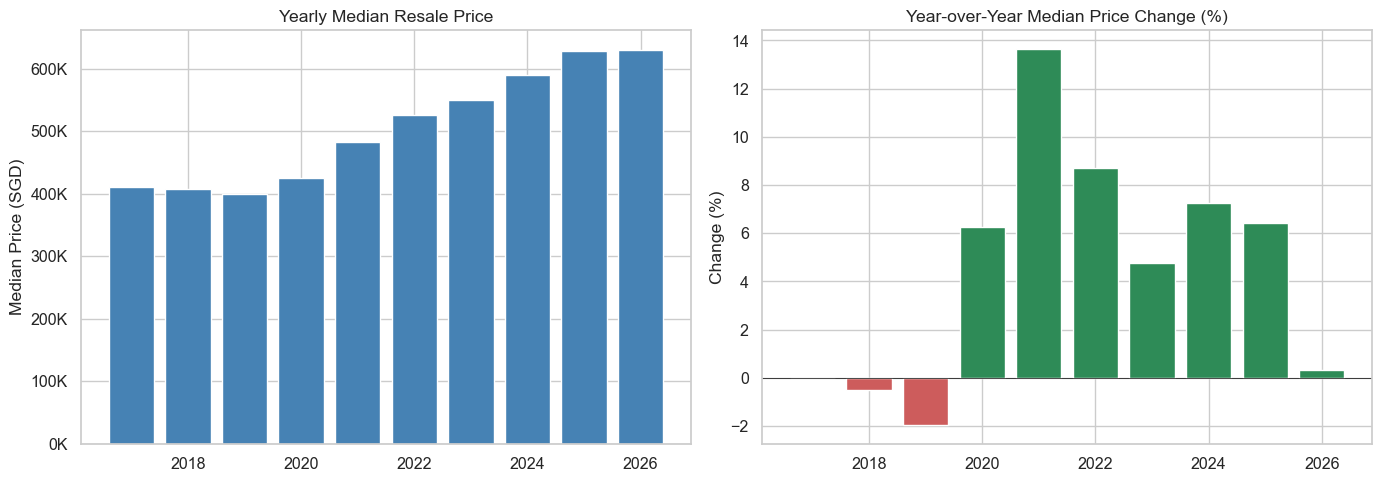

In [30]:
yearly = df.groupby("year")["resale_price"].median().reset_index()
yearly["yoy_change_pct"] = yearly["resale_price"].pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(yearly["year"], yearly["resale_price"], color="steelblue")
axes[0].set_title("Yearly Median Resale Price")
axes[0].set_ylabel("Median Price (SGD)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

colors = ["seagreen" if v >= 0 else "indianred" for v in yearly["yoy_change_pct"].fillna(0)]
axes[1].bar(yearly["year"], yearly["yoy_change_pct"].fillna(0), color=colors)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_title("Year-over-Year Median Price Change (%)")
axes[1].set_ylabel("Change (%)")

plt.tight_layout()
plt.show()

**YoY trend:** Median resale prices were relatively flat from 2017–2019, then surged sharply from 2020 onward — likely driven by post-COVID demand, low interest rates, and construction delays. The strongest year-over-year jumps occurred in 2021–2022.

### 3.9 Outlier Detection

In [32]:
Q1 = df["resale_price"].quantile(0.25)
Q3 = df["resale_price"].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

mask = (df["resale_price"] < lower) | (df["resale_price"] > upper)
outliers = df.loc[mask]
print(f"IQR bounds: [{lower:,.0f}, {upper:,.0f}]")
print(f"Outliers: {len(outliers):,} rows ({len(outliers) / len(df) * 100:.2f}%)")
print(f"\nOutlier resale_price range: [{outliers['resale_price'].min():,.0f}, {outliers['resale_price'].max():,.0f}]")
print(f"\nOutlier breakdown by flat_type:")
print(outliers["flat_type"].value_counts())

IQR bounds: [17,500, 1,005,500]
Outliers: 3,928 rows (1.76%)

Outlier resale_price range: [1,005,888, 1,700,000]

Outlier breakdown by flat_type:
flat_type
5 ROOM              1712
4 ROOM              1280
EXECUTIVE            910
3 ROOM                16
MULTI-GENERATION      10
Name: count, dtype: int64


**Outlier summary:** Only 1.76% of transactions (3,928 rows) exceed the IQR upper bound of SGD ~1M. These are almost exclusively 5-ROOM (1,712) and EXECUTIVE (910) flats, confirming that high-end outliers are driven by larger flat types rather than data errors.

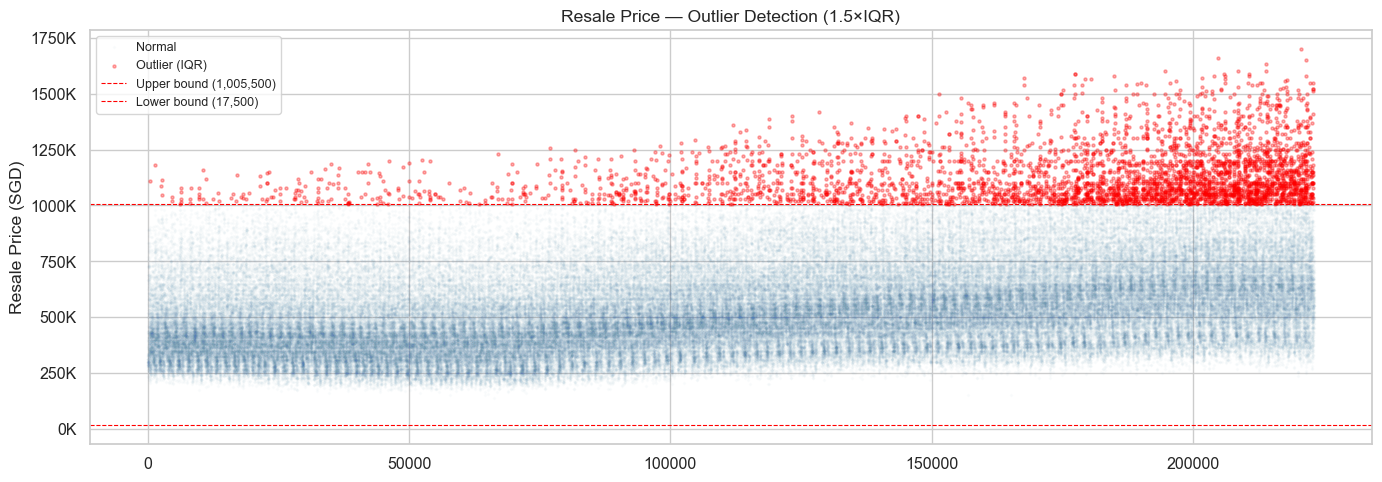

In [33]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(df.index, df["resale_price"], alpha=0.02, s=2, color="steelblue", label="Normal")
ax.scatter(outliers.index, outliers["resale_price"], alpha=0.3, s=5, color="red", label="Outlier (IQR)")
ax.axhline(upper, color="red", linestyle="--", linewidth=0.8, label=f"Upper bound ({upper:,.0f})")
ax.axhline(lower, color="red", linestyle="--", linewidth=0.8, label=f"Lower bound ({lower:,.0f})")
ax.set_title("Resale Price — Outlier Detection (1.5×IQR)")
ax.set_ylabel("Resale Price (SGD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Outlier scatter:** The upper-bound outliers (red) form a clear band above ~SGD 1M, concentrated among larger flat types. The lower IQR bound (SGD 17.5k) is effectively non-binding — no transactions fall below it.

### 3.10 Pair Plot — Numeric Features (sampled)

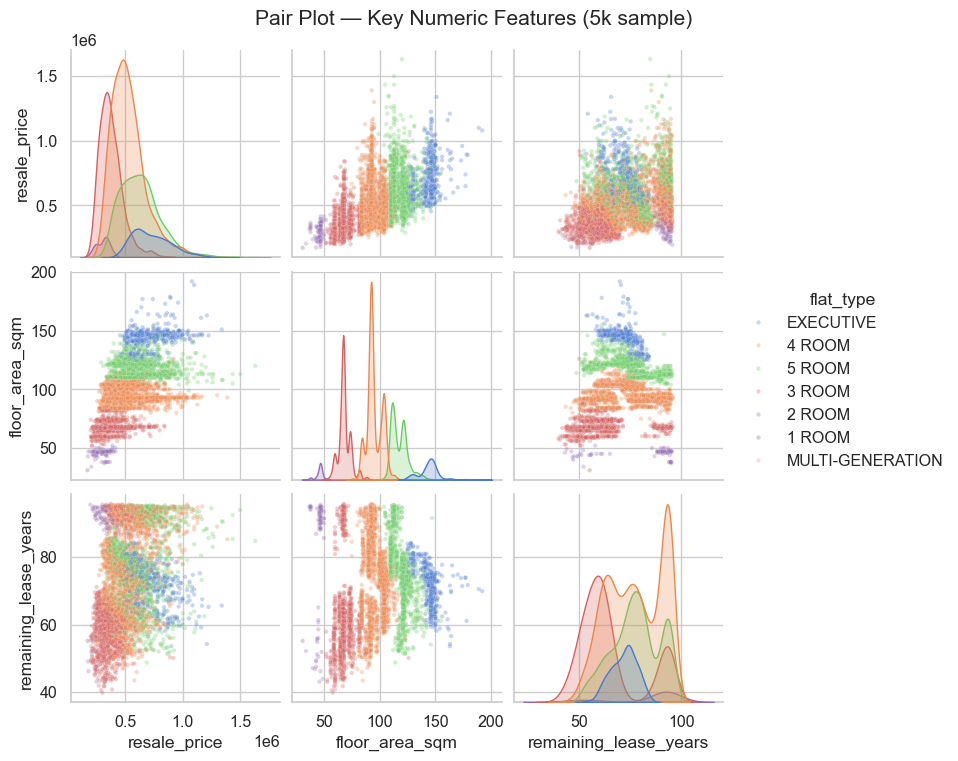

In [34]:
sample = df.sample(n=min(5000, len(df)), random_state=42)
pair_cols = ["resale_price", "floor_area_sqm", "storey_mid", "remaining_lease_years"]
g = sns.pairplot(sample.loc[:, pair_cols + ["flat_type"]], hue="flat_type", height=2.5,
                 plot_kws={"alpha": 0.3, "s": 10}, diag_kind="kde")
g.figure.suptitle("Pair Plot — Key Numeric Features (5k sample)", y=1.01)
plt.show()

---
## Summary

| Finding | Detail |
|---------|--------|
| **Rows** | ~223k resale transactions (2017-01 to 2026-03) |
| **Nulls** | Zero nulls across all columns |
| **Target** | `resale_price` is right-skewed; log transform may help for modelling |
| **Key drivers** | Floor area, flat type, storey, remaining lease, town |
| **Trend** | Steady upward price trend since 2020 |
| **Outliers** | High-end transactions (EXECUTIVE, 5-ROOM) drive upper-tail outliers |
| **Lease decay** | Clear price-per-sqm drop as remaining lease falls below ~60 years |

- After target distribution: right-skew, log transform recommended
- After time-series: broad-based post-2020 rally
- After town comparison: central vs. peripheral price gaps
- After flat type/model: 4-ROOM and 5-ROOM dominate volume
- After storey & area: higher floors command premium, area fans out
- After lease decay: sharp cliff below 60 years
- After correlation matrix: floor area is strongest driver
- After YoY change: 2021–2022 had the strongest jumps
- After outlier detection: 1.76% upper-tail, driven by large flat types
- After outlier scatter: band above ~SGD 1M